In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" All libraries imported successfully")

 All libraries imported successfully


In [2]:
DATA_PATH = "../data/digital_marketing_campaign_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"  Dataset loaded")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

  Dataset loaded
   Rows    : 8,000
   Columns : 20


In [3]:
df.head()


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [4]:
print("── Column Info ──────────────────────────────────────────")
print(df.dtypes)


── Column Info ──────────────────────────────────────────
CustomerID               int64
Age                      int64
Gender                     str
Income                   int64
CampaignChannel            str
CampaignType               str
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform        str
AdvertisingTool            str
Conversion               int64
dtype: object


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CustomerID,8000.0,11999.50,2309.55,8000.00,9999.75,11999.50,13999.25,15999.00
Age,8000.0,43.63,14.90,18.00,31.00,43.00,56.00,69.00
Income,8000.0,84664.20,37580.39,20014.00,51744.50,84926.50,116815.75,149986.00
AdSpend,8000.0,5000.94,2838.04,100.05,2523.22,5013.44,7407.99,9997.91
ClickThroughRate,8000.0,0.15,0.08,0.01,0.08,0.15,0.23,0.30
ConversionRate,8000.0,0.10,0.05,0.01,0.06,0.10,0.15,0.20
WebsiteVisits,8000.0,24.75,14.31,0.00,13.00,25.00,37.00,49.00
PagesPerVisit,8000.0,5.55,2.61,1.00,3.30,5.53,7.84,10.00
TimeOnSite,8000.0,7.73,4.23,0.50,4.07,7.68,11.48,15.00
SocialShares,8000.0,49.80,28.90,0.00,25.00,50.00,75.00,99.00


In [6]:
print("── Missing Values ───────────────────────────────────────")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  None found ")

print("\n── Duplicate Rows ───────────────────────────────────────")
dupes = df.duplicated().sum()
print(f"  {dupes} duplicates found" if dupes > 0 else "  None found ")

── Missing Values ───────────────────────────────────────
  None found 

── Duplicate Rows ───────────────────────────────────────
  None found 


── Target Variable: Conversion ──────────────────────────
                   Count  Percentage
No Conversion (0)   7012       87.65
Conversion (1)       988       12.35


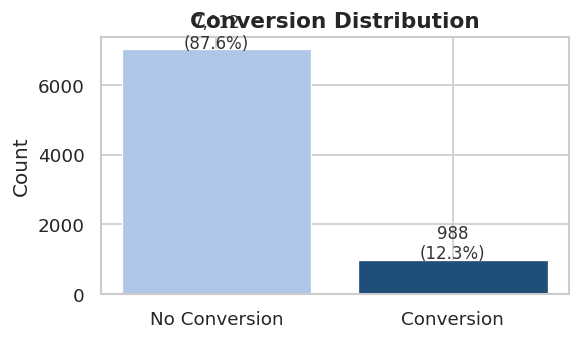

 Chart saved


In [7]:
print("── Target Variable: Conversion ──────────────────────────")
counts = df['Conversion'].value_counts()
pcts   = df['Conversion'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count'      : counts,
    'Percentage' : pcts.round(2)
})
summary.index = ['No Conversion (0)', 'Conversion (1)']
print(summary)

# Quick bar chart
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No Conversion', 'Conversion'], counts.values,
       color=['#AEC6E8','#1F4E79'], edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v:,}\n({pcts.values[i]:.1f}%)',
            ha='center', fontsize=10, color='#333')
ax.set_title('Conversion Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/01_target_distribution.png', bbox_inches='tight')
plt.show()
print(" Chart saved")

In [8]:
raw_df = df.copy()
print(" Raw copy stored as raw_df")
print(f"   Categorical columns : {list(df.select_dtypes('object').columns)}")

 Raw copy stored as raw_df
   Categorical columns : ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']


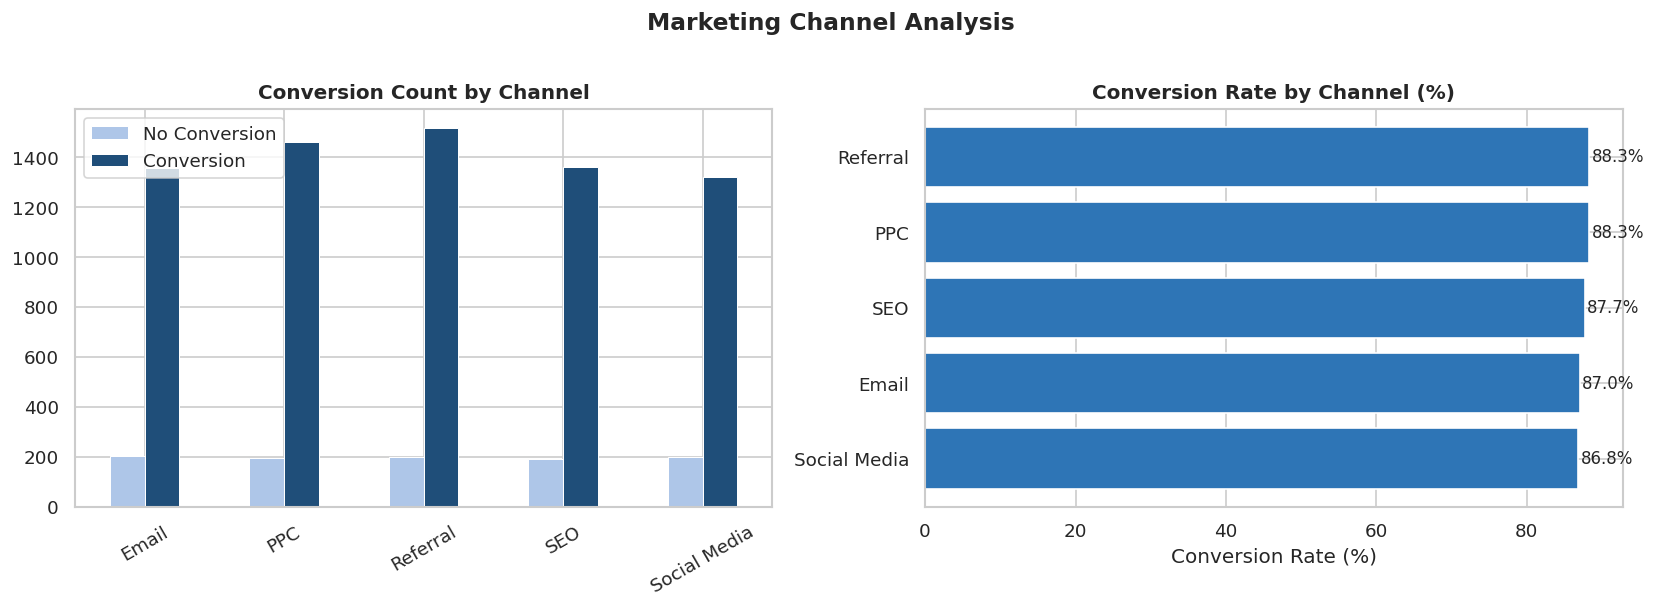

 Saved: 02_channel_analysis.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of conversions per channel
channel_conv = raw_df.groupby(['CampaignChannel', 'Conversion']).size().unstack(fill_value=0)
channel_conv.columns = ['No Conversion', 'Conversion']
channel_conv.plot(kind='bar', ax=axes[0], color=['#AEC6E8','#1F4E79'],
                  edgecolor='white', linewidth=0.6)
axes[0].set_title('Conversion Count by Channel', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Conversion RATE per channel
conv_rate = raw_df.groupby('CampaignChannel')['Conversion'].mean() * 100
conv_rate_sorted = conv_rate.sort_values(ascending=True)
bars = axes[1].barh(conv_rate_sorted.index, conv_rate_sorted.values,
                    color='#2E75B6', edgecolor='white')
for bar, val in zip(bars, conv_rate_sorted.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[1].set_title('Conversion Rate by Channel (%)', fontweight='bold')
axes[1].set_xlabel('Conversion Rate (%)')

plt.suptitle('Marketing Channel Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/02_channel_analysis.png', bbox_inches='tight')
plt.show()
print(" Saved: 02_channel_analysis.png")

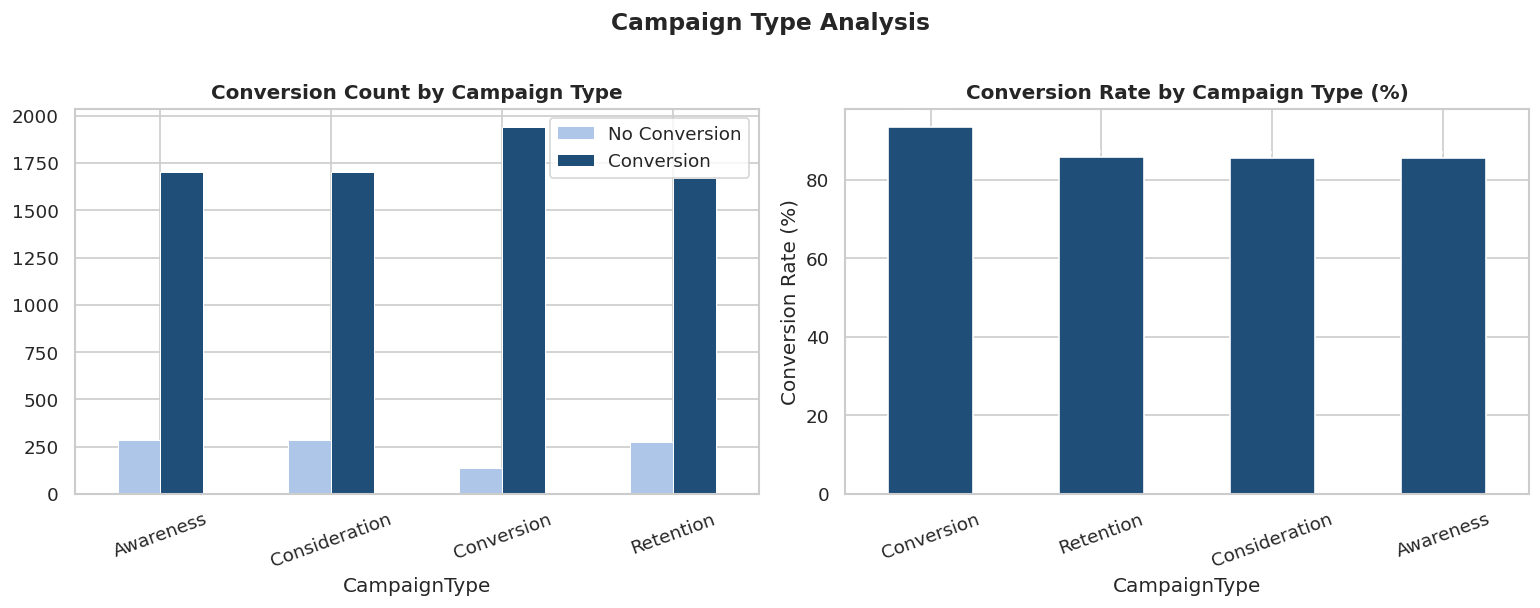

 Saved: 03_campaign_type_analysis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count
ctype_conv = raw_df.groupby(['CampaignType','Conversion']).size().unstack(fill_value=0)
ctype_conv.columns = ['No Conversion','Conversion']
ctype_conv.plot(kind='bar', ax=axes[0], color=['#AEC6E8','#1F4E79'],
                edgecolor='white', linewidth=0.6)
axes[0].set_title('Conversion Count by Campaign Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Rate
ctype_rate = raw_df.groupby('CampaignType')['Conversion'].mean() * 100
ctype_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[1],
    color='#1F4E79', edgecolor='white')
for i, v in enumerate(ctype_rate.sort_values(ascending=False)):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10, color='white',
                 fontweight='bold', va='bottom')
axes[1].set_title('Conversion Rate by Campaign Type (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Conversion Rate (%)')

plt.suptitle('Campaign Type Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/03_campaign_type_analysis.png', bbox_inches='tight')
plt.show()
print(" Saved: 03_campaign_type_analysis.png")

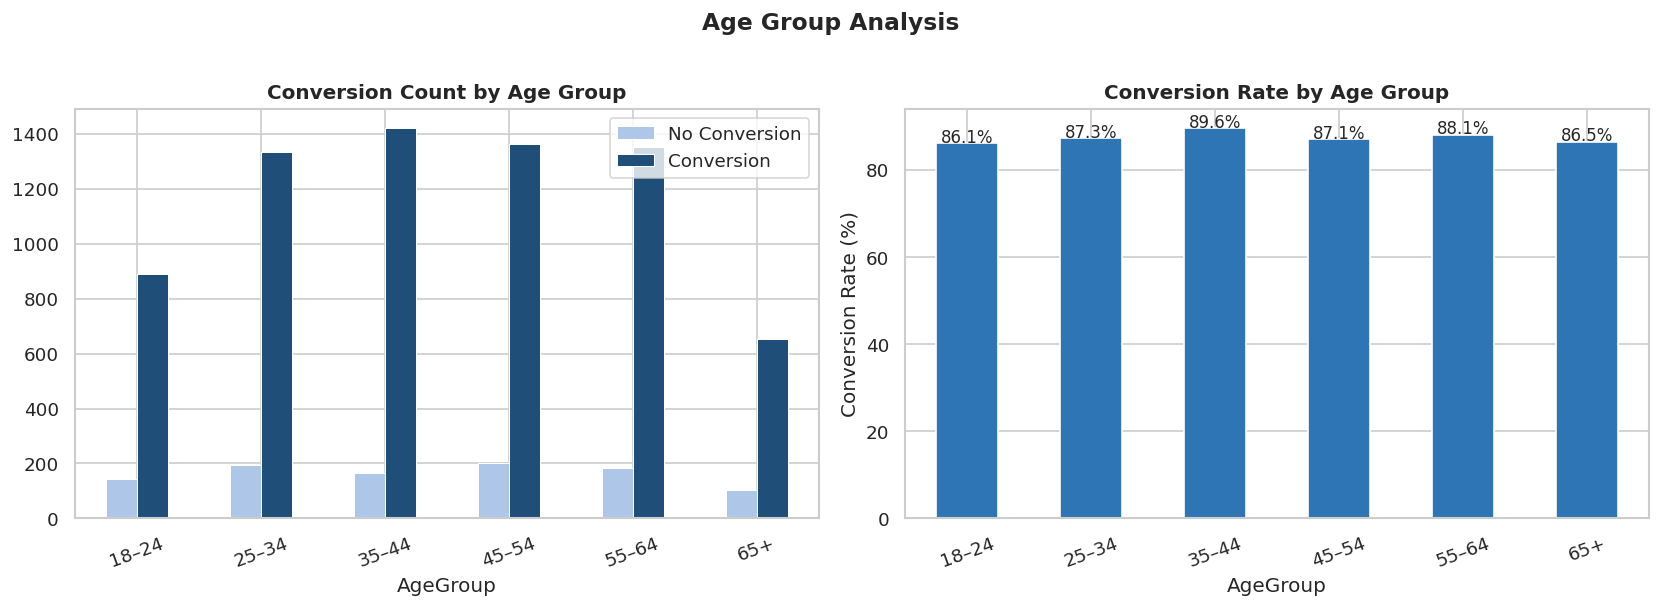

 Saved: 04_age_group_analysis.png


In [11]:
# Bin ages into groups
raw_df['AgeGroup'] = pd.cut(raw_df['Age'],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=['18–24','25–34','35–44','45–54','55–64','65+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_rate = raw_df.groupby('AgeGroup', observed=True)['Conversion'].mean() * 100
age_count = raw_df.groupby(['AgeGroup','Conversion'], observed=True).size().unstack(fill_value=0)
age_count.columns = ['No Conversion','Conversion']

age_count.plot(kind='bar', ax=axes[0], color=['#AEC6E8','#1F4E79'],
               edgecolor='white', linewidth=0.6)
axes[0].set_title('Conversion Count by Age Group', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

age_rate.plot(kind='bar', ax=axes[1], color='#2E75B6', edgecolor='white')
for i, v in enumerate(age_rate):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Conversion Rate by Age Group', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Age Group Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/04_age_group_analysis.png', bbox_inches='tight')
plt.show()
print(" Saved: 04_age_group_analysis.png")

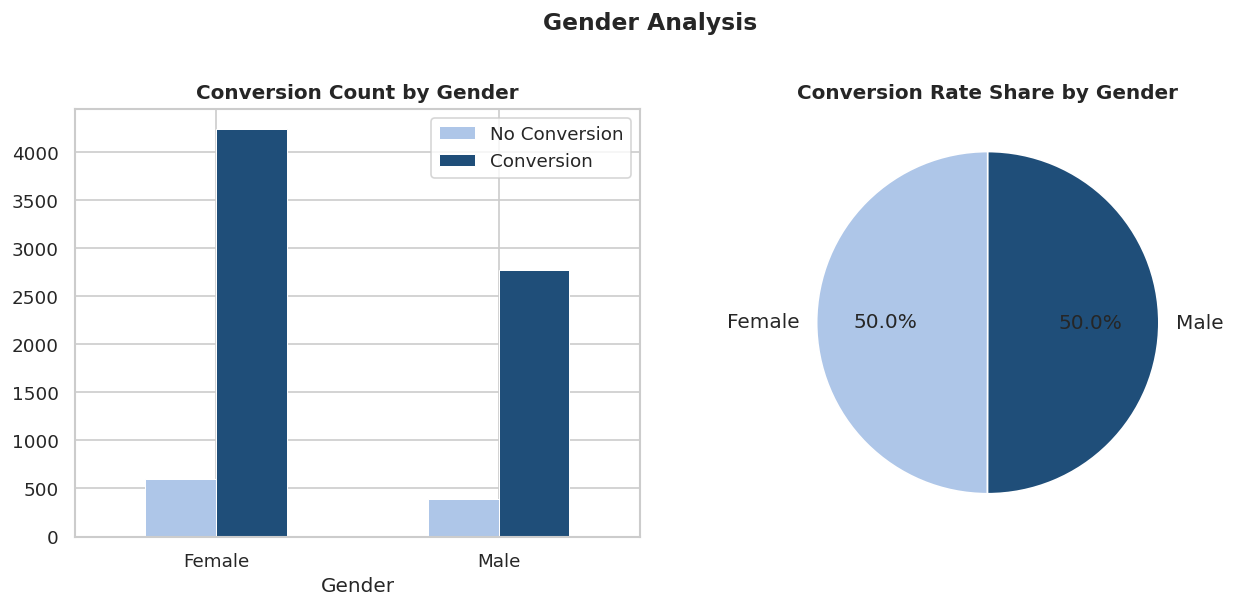

 Saved: 05_gender_analysis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

gender_rate = raw_df.groupby('Gender')['Conversion'].mean() * 100
gender_count = raw_df.groupby(['Gender','Conversion']).size().unstack(fill_value=0)
gender_count.columns = ['No Conversion','Conversion']

gender_count.plot(kind='bar', ax=axes[0], color=['#AEC6E8','#1F4E79'],
                  edgecolor='white', linewidth=0.6)
axes[0].set_title('Conversion Count by Gender', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

axes[1].pie(gender_rate.values, labels=gender_rate.index,
            autopct='%1.1f%%', colors=['#AEC6E8','#1F4E79'],
            startangle=90, textprops={'fontsize':12})
axes[1].set_title('Conversion Rate Share by Gender', fontweight='bold')

plt.suptitle('Gender Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/05_gender_analysis.png', bbox_inches='tight')
plt.show()
print(" Saved: 05_gender_analysis.png")

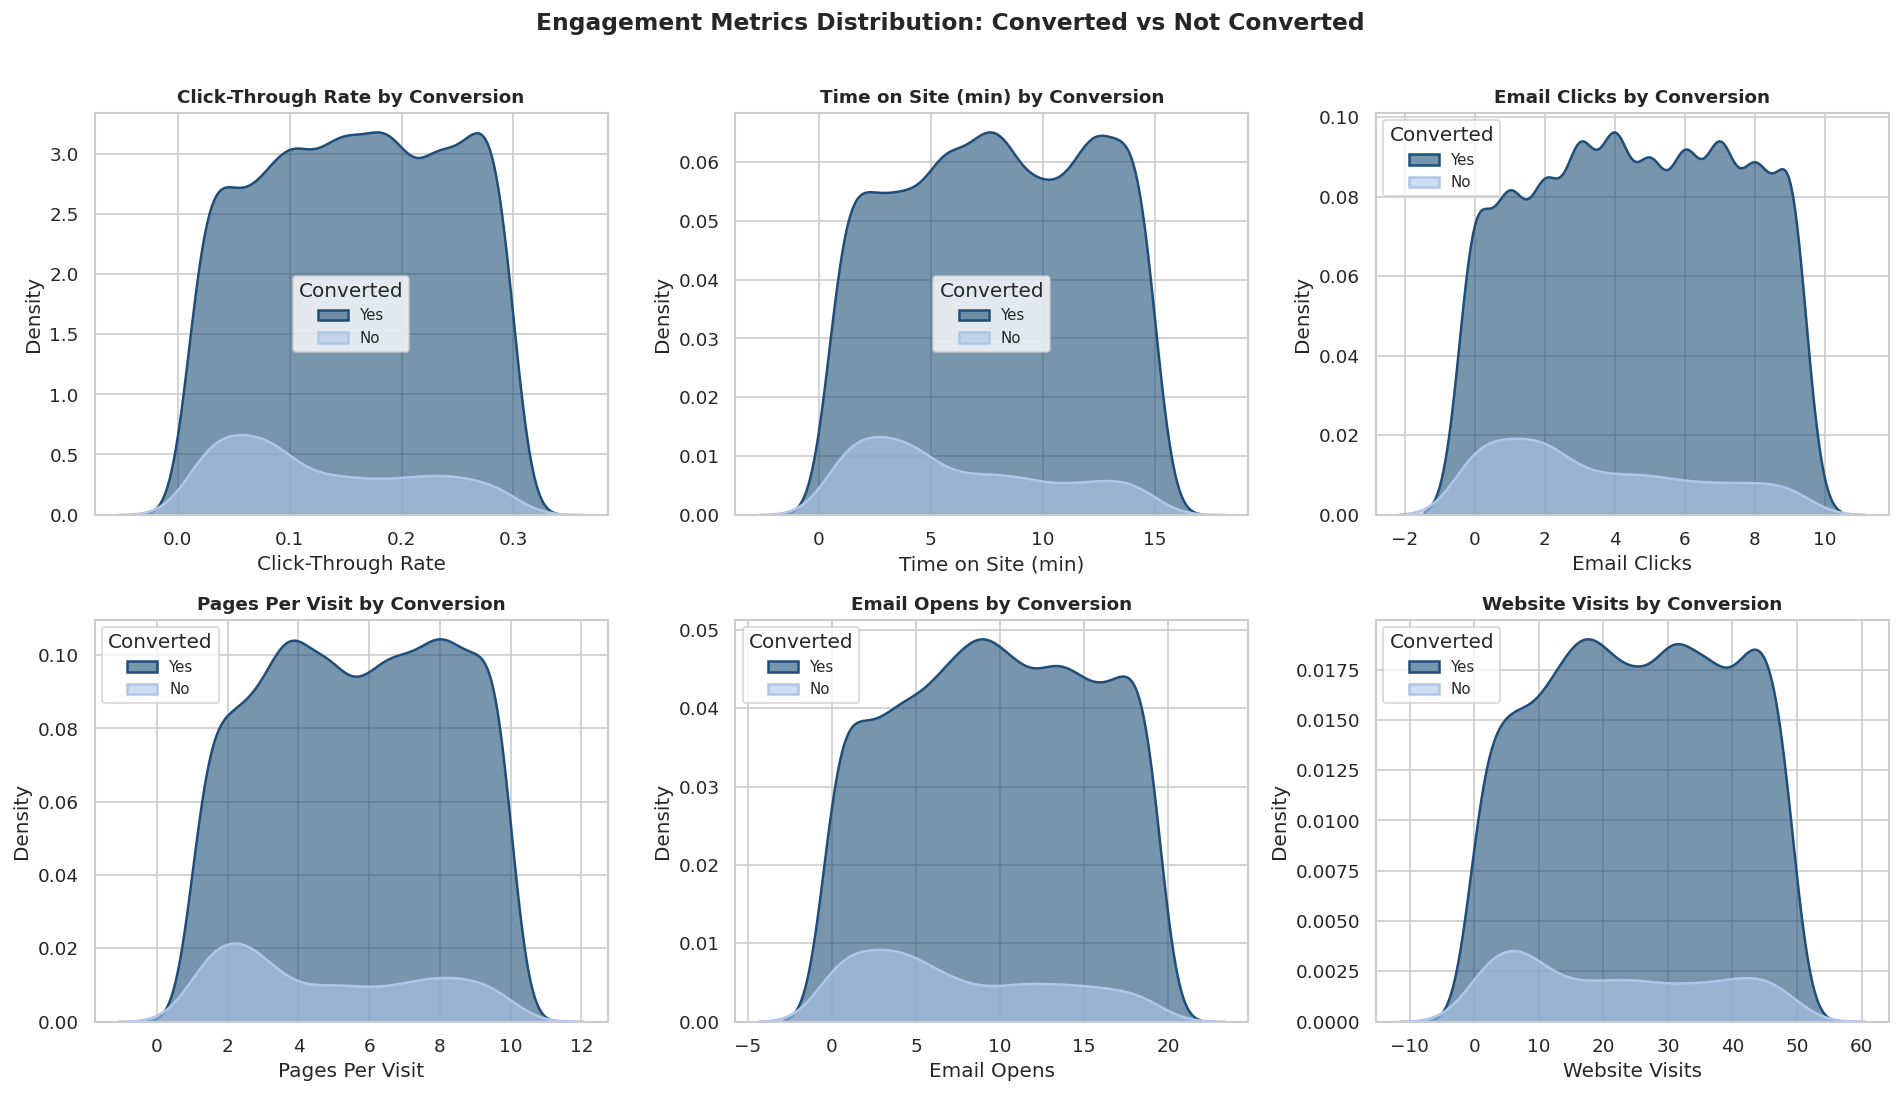

 Saved: 06_engagement_kde.png


In [13]:
# These show how the distribution of each metric differs between
# converted and non-converted users — key for understanding predictors

features_to_plot = [
    ('ClickThroughRate', 'Click-Through Rate'),
    ('TimeOnSite',       'Time on Site (min)'),
    ('EmailClicks',      'Email Clicks'),
    ('PagesPerVisit',    'Pages Per Visit'),
    ('EmailOpens',       'Email Opens'),
    ('WebsiteVisits',    'Website Visits'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(features_to_plot):
    sns.kdeplot(data=raw_df, x=col, hue='Conversion', fill=True,
                palette={0:'#AEC6E8', 1:'#1F4E79'}, alpha=0.6,
                ax=axes[i], linewidth=1.5)
    axes[i].set_title(f'{label} by Conversion', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(label)
    axes[i].legend(title='Converted', labels=['Yes','No'], fontsize=9)

plt.suptitle('Engagement Metrics Distribution: Converted vs Not Converted',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/06_engagement_kde.png', bbox_inches='tight')
plt.show()
print(" Saved: 06_engagement_kde.png")

── Feature Correlation with Conversion ──────────────────
TimeOnSite           0.1296
EmailClicks          0.1295
EmailOpens           0.1249
AdSpend              0.1247
ClickThroughRate     0.1200
PreviousPurchases    0.1118
PagesPerVisit        0.1028
LoyaltyPoints        0.0950
ConversionRate       0.0932
WebsiteVisits        0.0793
Income               0.0140
Age                  0.0016
SocialShares        -0.0114
CustomerID          -0.1807


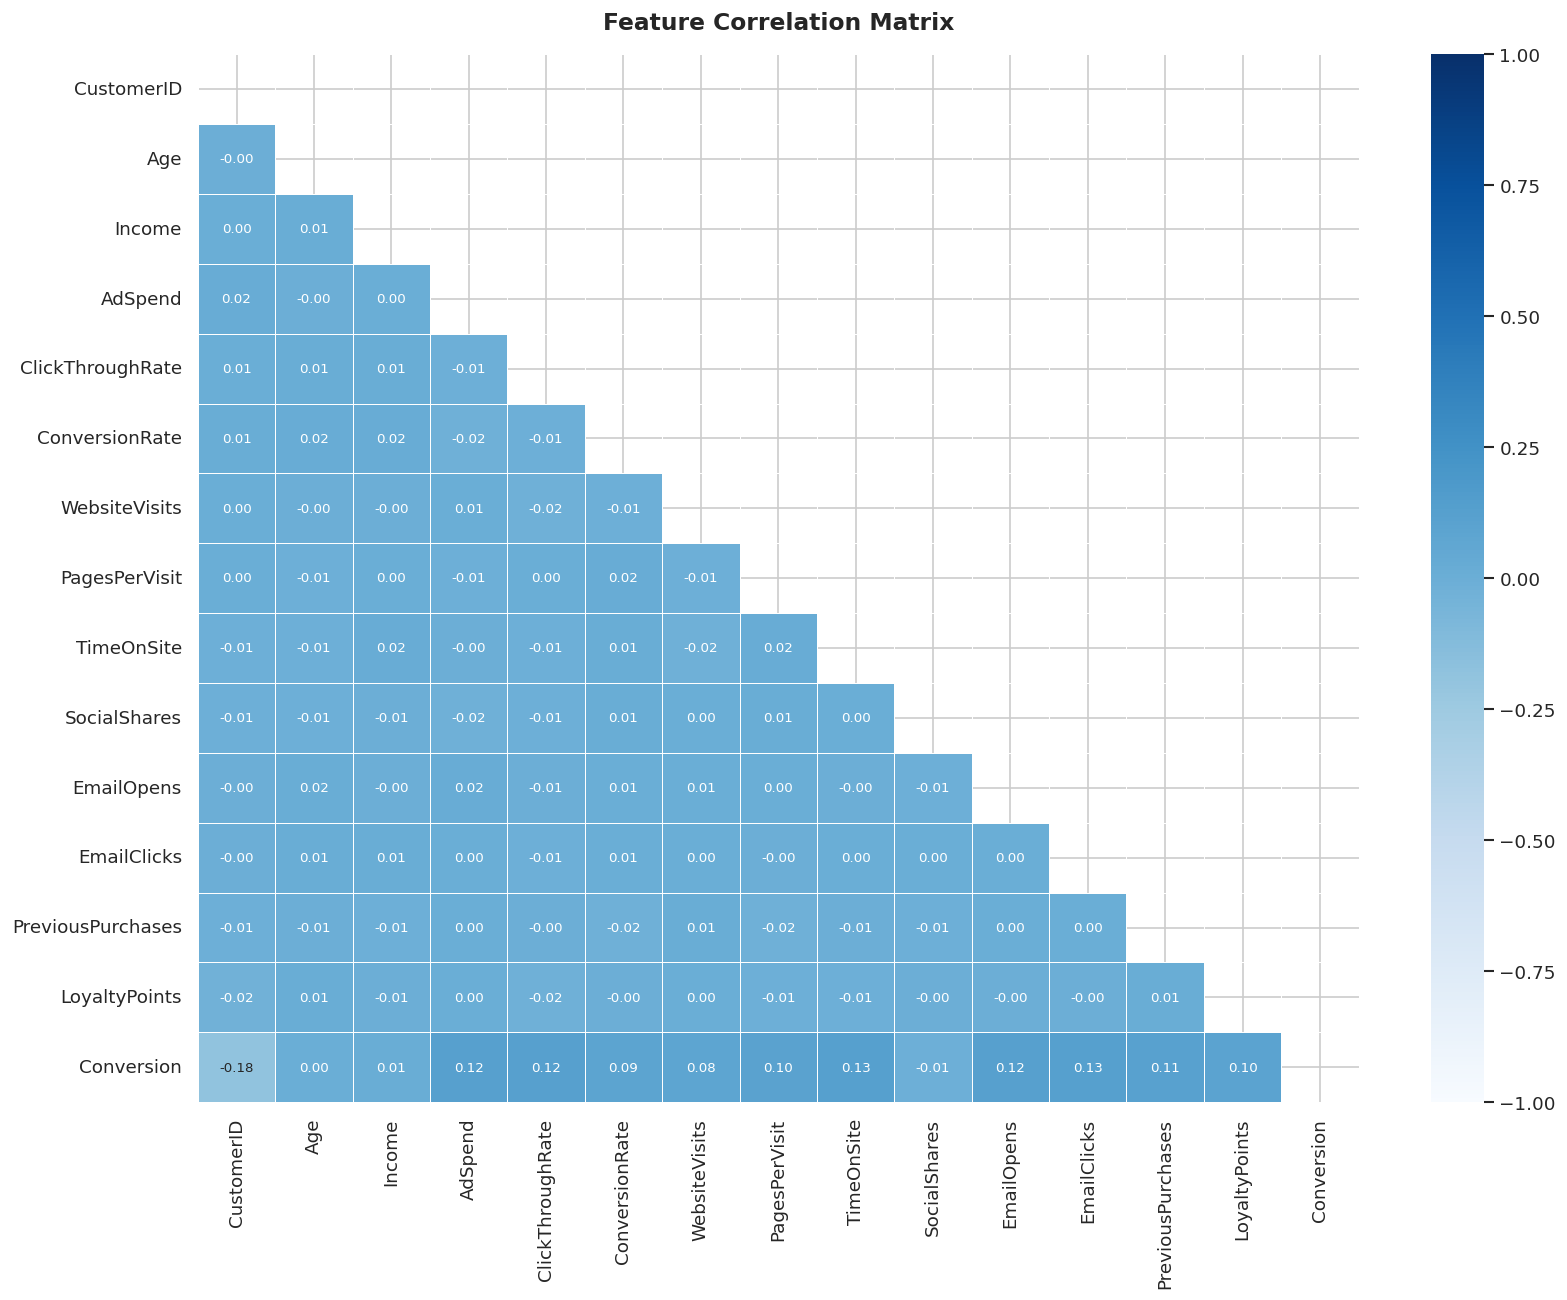

 Saved: 07_correlation_heatmap.png


In [14]:
# Numeric columns only
num_cols = raw_df.select_dtypes(include=[np.number]).columns.tolist()
corr = raw_df[num_cols].corr()

# Sort by correlation with Conversion
conv_corr = corr['Conversion'].drop('Conversion').sort_values(ascending=False)
print("── Feature Correlation with Conversion ──────────────────")
print(conv_corr.round(4).to_string())

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print(" Saved: 07_correlation_heatmap.png")

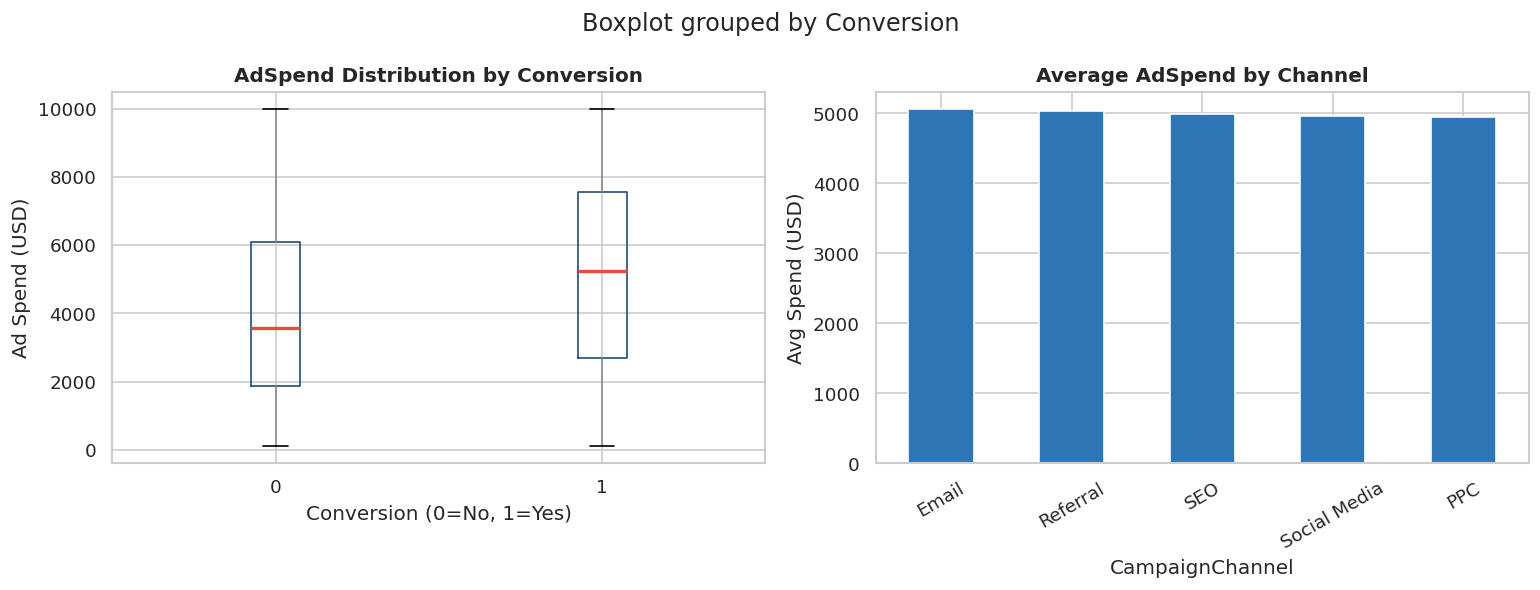

 Saved: 08_adspend_analysis.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
raw_df.boxplot(column='AdSpend', by='Conversion', ax=axes[0],
               boxprops=dict(color='#1F4E79'),
               medianprops=dict(color='#E74C3C', linewidth=2))
axes[0].set_title('AdSpend Distribution by Conversion', fontweight='bold')
axes[0].set_xlabel('Conversion (0=No, 1=Yes)')
axes[0].set_ylabel('Ad Spend (USD)')
plt.sca(axes[0])
plt.title('AdSpend Distribution by Conversion', fontweight='bold')

# Average spend per channel
avg_spend = raw_df.groupby('CampaignChannel')['AdSpend'].mean().sort_values(ascending=False)
avg_spend.plot(kind='bar', ax=axes[1], color='#2E75B6', edgecolor='white')
axes[1].set_title('Average AdSpend by Channel', fontweight='bold')
axes[1].set_ylabel('Avg Spend (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/08_adspend_analysis.png', bbox_inches='tight')
plt.show()
print(" Saved: 08_adspend_analysis.png")

In [16]:
print("=" * 60)
print("  EDA SUMMARY")
print("=" * 60)

print("\n📊 Conversion Rate by Channel:")
cr = raw_df.groupby('CampaignChannel')['Conversion'].mean()*100
for ch, rate in cr.sort_values(ascending=False).items():
    bar = "█" * int(rate / 2)
    print(f"  {ch:<15} {rate:.1f}% {bar}")

print("\n📊 Conversion Rate by Campaign Type:")
ct = raw_df.groupby('CampaignType')['Conversion'].mean()*100
for t, rate in ct.sort_values(ascending=False).items():
    bar = "█" * int(rate / 2)
    print(f"  {t:<20} {rate:.1f}% {bar}")

print("\n📊 Conversion Rate by Age Group:")
ag = raw_df.groupby('AgeGroup', observed=True)['Conversion'].mean()*100
for g, rate in ag.sort_values(ascending=False).items():
    bar = "█" * int(rate / 2)
    print(f"  {str(g):<10} {rate:.1f}% {bar}")

print("\n📊 Conversion Rate by Gender:")
gd = raw_df.groupby('Gender')['Conversion'].mean()*100
for g, rate in gd.sort_values(ascending=False).items():
    print(f"  {g:<10} {rate:.1f}%")

print("\n📊 Top 5 Features Correlated with Conversion:")
for feat, val in conv_corr.head(5).items():
    print(f"  {feat:<25} {val:+.4f}")
print("=" * 60)

  EDA SUMMARY

📊 Conversion Rate by Channel:
  Referral        88.3% ████████████████████████████████████████████
  PPC             88.3% ████████████████████████████████████████████
  SEO             87.7% ███████████████████████████████████████████
  Email           87.0% ███████████████████████████████████████████
  Social Media    86.8% ███████████████████████████████████████████

📊 Conversion Rate by Campaign Type:
  Conversion           93.4% ██████████████████████████████████████████████
  Retention            85.8% ██████████████████████████████████████████
  Consideration        85.6% ██████████████████████████████████████████
  Awareness            85.6% ██████████████████████████████████████████

📊 Conversion Rate by Age Group:
  35–44      89.6% ████████████████████████████████████████████
  55–64      88.1% ████████████████████████████████████████████
  25–34      87.3% ███████████████████████████████████████████
  45–54      87.1% █████████████████████████████████████████

In [17]:
model_df = raw_df.copy()

cols_to_drop = ['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool', 'AgeGroup']

cols_to_drop = [c for c in cols_to_drop if c in model_df.columns]
model_df.drop(columns=cols_to_drop, inplace=True)

print(f"  Dropped: {cols_to_drop}")
print(f"   Remaining columns ({len(model_df.columns)}): {list(model_df.columns)}")

  Dropped: ['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool', 'AgeGroup']
   Remaining columns (17): ['Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'Conversion']


In [18]:
cat_cols = ['Gender', 'CampaignChannel', 'CampaignType']

model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

print(f"  One-hot encoding done")
print(f"   Total features now: {model_df.shape[1] - 1} (+ 1 target)")
print(f"   New columns: {[c for c in model_df.columns if any(cat in c for cat in cat_cols)]}")

  One-hot encoding done
   Total features now: 21 (+ 1 target)
   New columns: ['Gender_Male', 'CampaignChannel_PPC', 'CampaignChannel_Referral', 'CampaignChannel_SEO', 'CampaignChannel_Social Media', 'CampaignType_Consideration', 'CampaignType_Conversion', 'CampaignType_Retention']


In [19]:
X = model_df.drop(columns=['Conversion'])
y = model_df['Conversion']

print(f" Features (X): {X.shape}")
print(f" Target  (y): {y.shape}")
print(f"\n   Feature columns:\n   {list(X.columns)}")

 Features (X): (8000, 21)
 Target  (y): (8000,)

   Feature columns:
   ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'Gender_Male', 'CampaignChannel_PPC', 'CampaignChannel_Referral', 'CampaignChannel_SEO', 'CampaignChannel_Social Media', 'CampaignType_Consideration', 'CampaignType_Conversion', 'CampaignType_Retention']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"  Train / Test split complete")
print(f"   X_train : {X_train.shape}  | y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}   | y_test  : {y_test.shape}")
print(f"\n   Train conversion rate: {y_train.mean()*100:.2f}%")
print(f"   Test  conversion rate: {y_test.mean()*100:.2f}%")

  Train / Test split complete
   X_train : (6400, 21)  | y_train : (6400,)
   X_test  : (1600, 21)   | y_test  : (1600,)

   Train conversion rate: 87.66%
   Test  conversion rate: 87.62%


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # only transform test (no data leakage!)

X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X_test.columns)

print("  Scaling complete (StandardScaler)")
print("   fit_transform on TRAIN only → transform on TEST (no leakage)")

  Scaling complete (StandardScaler)
   fit_transform on TRAIN only → transform on TEST (no leakage)


In [22]:

def add_features(df):
    df = df.copy()
    
    df['SpendPerVisit'] = df['AdSpend'] / (df['WebsiteVisits'] + 1)
    
    df['EmailEngagementRate'] = df['EmailClicks'] / (df['EmailOpens'] + 1)
    
    df['SessionScore'] = df['PagesPerVisit'] * df['TimeOnSite']
    
    df['LoyaltyScore'] = df['LoyaltyPoints'] * df['PreviousPurchases']
    
    return df

X_train = add_features(X_train)
X_test  = add_features(X_test)

X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),       columns=X_test.columns)

print(f"  Feature engineering complete")
print(f"   New features added: SpendPerVisit, EmailEngagementRate, SessionScore, LoyaltyScore")
print(f"   Total features now: {X_train.shape[1]}")

  Feature engineering complete
   New features added: SpendPerVisit, EmailEngagementRate, SessionScore, LoyaltyScore
   Total features now: 25


── Top 15 Features by ANOVA F-Score ─────────────────────
SessionScore                  140.84
TimeOnSite                    121.26
LoyaltyScore                  117.81
ClickThroughRate              109.28
EmailClicks                   106.26
AdSpend                        98.95
PreviousPurchases              97.72
EmailOpens                     90.07
PagesPerVisit                  73.63
LoyaltyPoints                  64.28
CampaignType_Conversion        60.60
ConversionRate                 57.51
WebsiteVisits                  35.46
CampaignType_Retention          8.70
CampaignType_Consideration      4.81


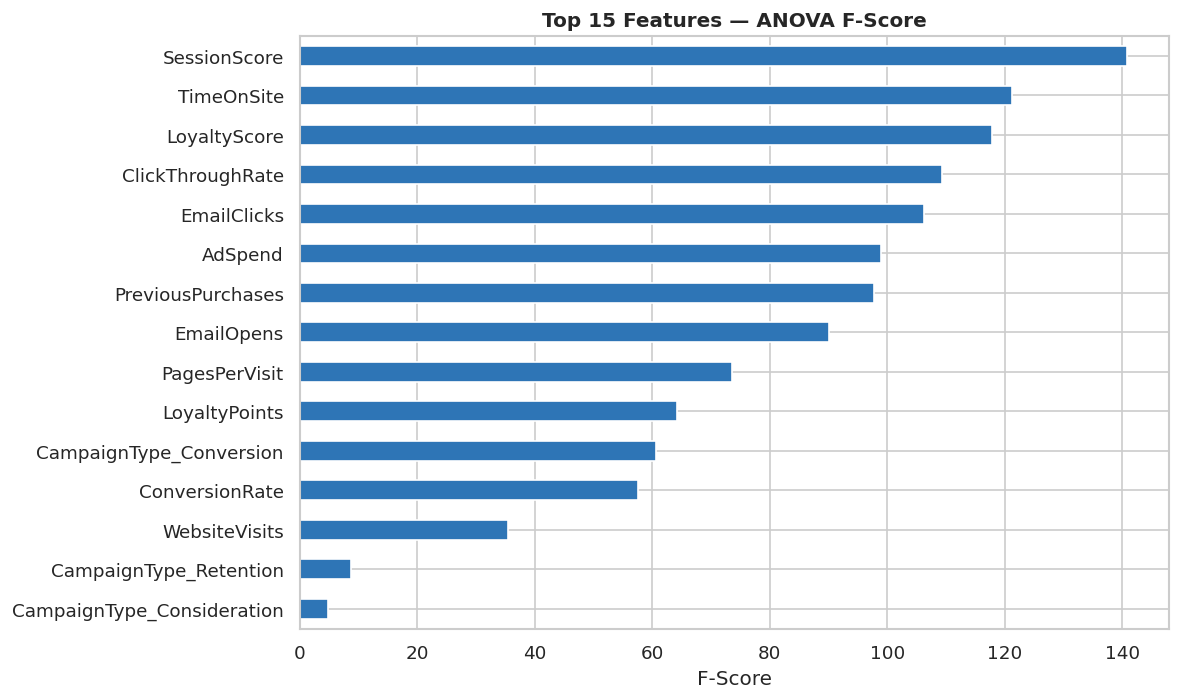

  Saved: 09_feature_scores.png


In [23]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

feat_scores = pd.Series(selector.scores_, index=X_train.columns)
feat_scores_sorted = feat_scores.sort_values(ascending=False)

print("── Top 15 Features by ANOVA F-Score ─────────────────────")
print(feat_scores_sorted.head(15).round(2).to_string())

plt.figure(figsize=(10, 6))
feat_scores_sorted.head(15).sort_values().plot(
    kind='barh', color='#2E75B6', edgecolor='white')
plt.title('Top 15 Features — ANOVA F-Score', fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('../outputs/09_feature_scores.png', bbox_inches='tight')
plt.show()
print("  Saved: 09_feature_scores.png")

In [24]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)   # uses scaled data

print("  Logistic Regression trained")
print(f"   Train accuracy: {lr.score(X_train_sc, y_train)*100:.2f}%")
print(f"   Test  accuracy: {lr.score(X_test_sc,  y_test)*100:.2f}%")

Training Logistic Regression...
  Logistic Regression trained
   Train accuracy: 89.42%
   Test  accuracy: 89.00%


In [25]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (this takes ~30 seconds)...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1   
)
rf.fit(X_train, y_train)  

print("  Random Forest trained")
print(f"   Train accuracy: {rf.score(X_train, y_train)*100:.2f}%")
print(f"   Test  accuracy: {rf.score(X_test,  y_test)*100:.2f}%")

Training Random Forest (this takes ~30 seconds)...
  Random Forest trained
   Train accuracy: 96.28%
   Test  accuracy: 89.12%


In [26]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("  XGBoost trained")
print(f"   Train accuracy: {xgb.score(X_train, y_train)*100:.2f}%")
print(f"   Test  accuracy: {xgb.score(X_test,  y_test)*100:.2f}%")

Training XGBoost...
  XGBoost trained
   Train accuracy: 99.23%
   Test  accuracy: 91.56%


In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold Cross-Validation...\n")

results = {}
for name, model, Xtr, ytr in [
    ('Logistic Regression', lr,  X_train_sc, y_train),
    ('Random Forest',       rf,  X_train,    y_train),
    ('XGBoost',             xgb, X_train,    y_train),
]:
    scores = cross_val_score(model, Xtr, ytr, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"  {name:<25}  AUC = {scores.mean():.4f} ± {scores.std():.4f}  "
          f"| Min: {scores.min():.4f}  Max: {scores.max():.4f}")

print("\n  Cross-validation complete")

Running 5-fold Cross-Validation...

  Logistic Regression        AUC = 0.7941 ± 0.0367  | Min: 0.7594  Max: 0.8603
  Random Forest              AUC = 0.8159 ± 0.0367  | Min: 0.7783  Max: 0.8676
  XGBoost                    AUC = 0.8231 ± 0.0412  | Min: 0.7684  Max: 0.8863

  Cross-validation complete


In [28]:
from sklearn.model_selection import GridSearchCV

print("Running GridSearchCV (takes 3–5 minutes)...")

param_grid = {
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1],
    'n_estimators'  : [200, 300],
    'subsample'     : [0.8, 1.0],
}

gs = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print(f"\n  Best parameters: {gs.best_params_}")
print(f"   Best AUC (CV): {gs.best_score_:.4f}")

best_xgb = gs.best_estimator_
print(f"\n   Test accuracy with best model: {best_xgb.score(X_test, y_test)*100:.2f}%")

Running GridSearchCV (takes 3–5 minutes)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

  Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
   Best AUC (CV): 0.8287

   Test accuracy with best model: 92.31%


In [29]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay, f1_score,
                              precision_score, recall_score, accuracy_score)

models_eval = [
    ('Logistic Regression', lr,       X_test_sc),
    ('Random Forest',       rf,       X_test),
    ('XGBoost (Tuned)',     best_xgb, X_test),
]

print("=" * 60)
for name, model, Xte in models_eval:
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    
    print(f"\n{'─'*60}")
    print(f"  MODEL: {name}")
    print(f"{'─'*60}")
    print(classification_report(y_test, y_pred,
          target_names=['No Conversion','Conversion']))
    print(f"  AUC-ROC Score : {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 60)


────────────────────────────────────────────────────────────
  MODEL: Logistic Regression
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

No Conversion       0.76      0.16      0.27       198
   Conversion       0.89      0.99      0.94      1402

     accuracy                           0.89      1600
    macro avg       0.83      0.58      0.60      1600
 weighted avg       0.88      0.89      0.86      1600

  AUC-ROC Score : 0.7858

────────────────────────────────────────────────────────────
  MODEL: Random Forest
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

No Conversion       0.88      0.14      0.24       198
   Conversion       0.89      1.00      0.94      1402

     accuracy                           0.89      1600
    macro avg       0.88      0.57      0.59      1600
 weighted avg       0.89      0.89      0.86      1600

  AUC-ROC S

In [30]:
print("\n── Metrics Comparison ───────────────────────────────────\n")
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC-ROC':>9}")
print("─" * 72)

comparison = {}
for name, model, Xte in models_eval:
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    
    comparison[name] = {'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1,'AUC':auc}
    print(f"{name:<25} {acc*100:>8.2f}% {prec*100:>9.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}% {auc:>9.4f}")


── Metrics Comparison ───────────────────────────────────

Model                      Accuracy  Precision   Recall       F1   AUC-ROC
────────────────────────────────────────────────────────────────────────
Logistic Regression          89.00%     89.35%   99.29%   94.05%    0.7858
Random Forest                89.12%     89.16%   99.71%   94.14%    0.8062
XGBoost (Tuned)              92.31%     92.49%   99.29%   95.77%    0.8160


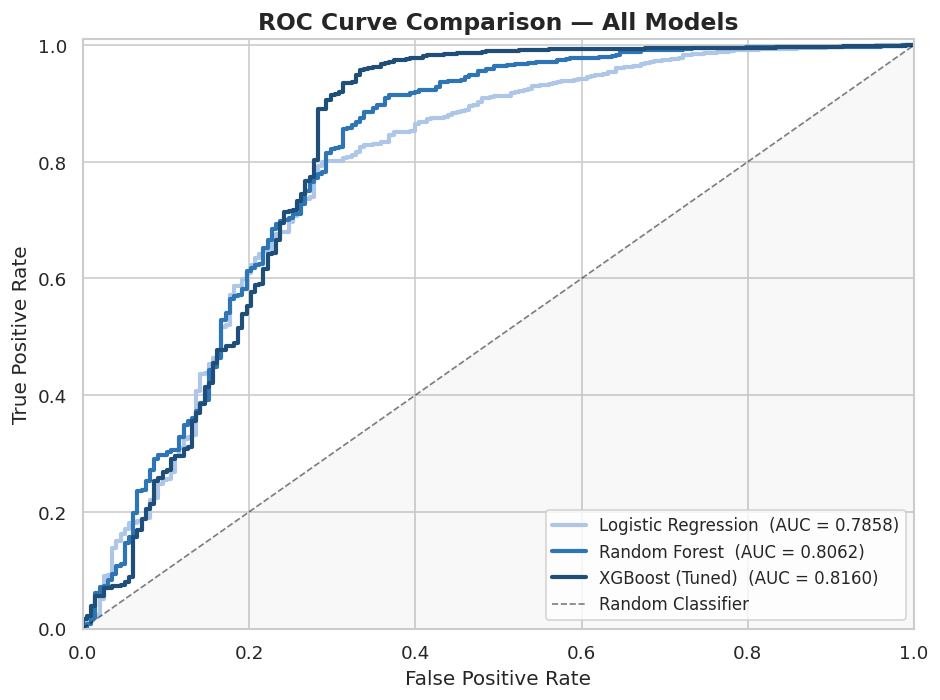

  Saved: 10_roc_curves.png


In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#AEC6E8', '#2E75B6', '#1F4E79']
for (name, model, Xte), color in zip(models_eval, colors):
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig('../outputs/10_roc_curves.png', bbox_inches='tight')
plt.show()
print("  Saved: 10_roc_curves.png")

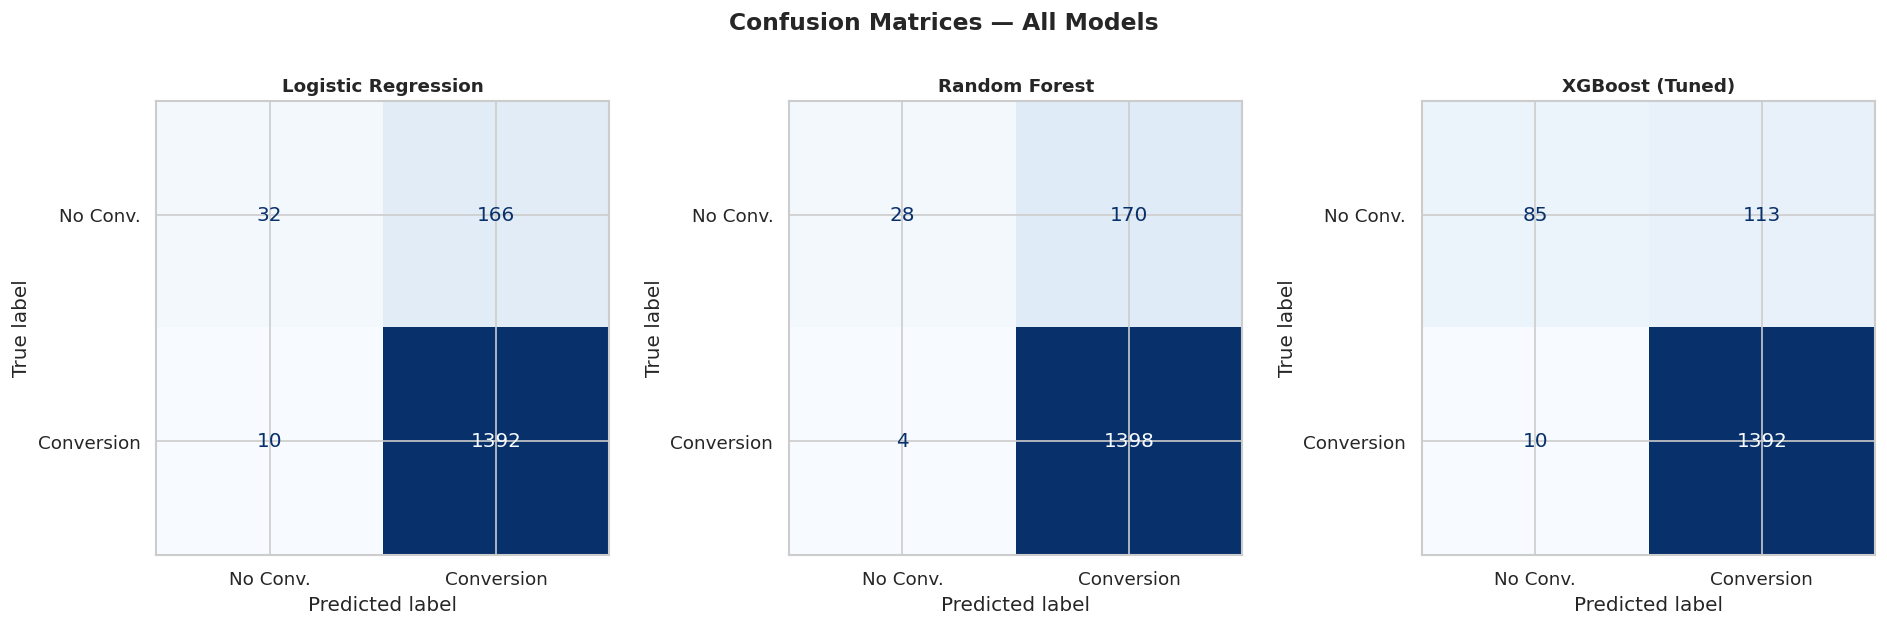

 Saved: 11_confusion_matrices.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model, Xte) in zip(axes, models_eval):
    ConfusionMatrixDisplay.from_estimator(
        model, Xte, y_test, ax=ax,
        display_labels=['No Conv.', 'Conversion'],
        cmap='Blues', colorbar=False
    )
    ax.set_title(name, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/11_confusion_matrices.png', bbox_inches='tight')
plt.show()
print(" Saved: 11_confusion_matrices.png")

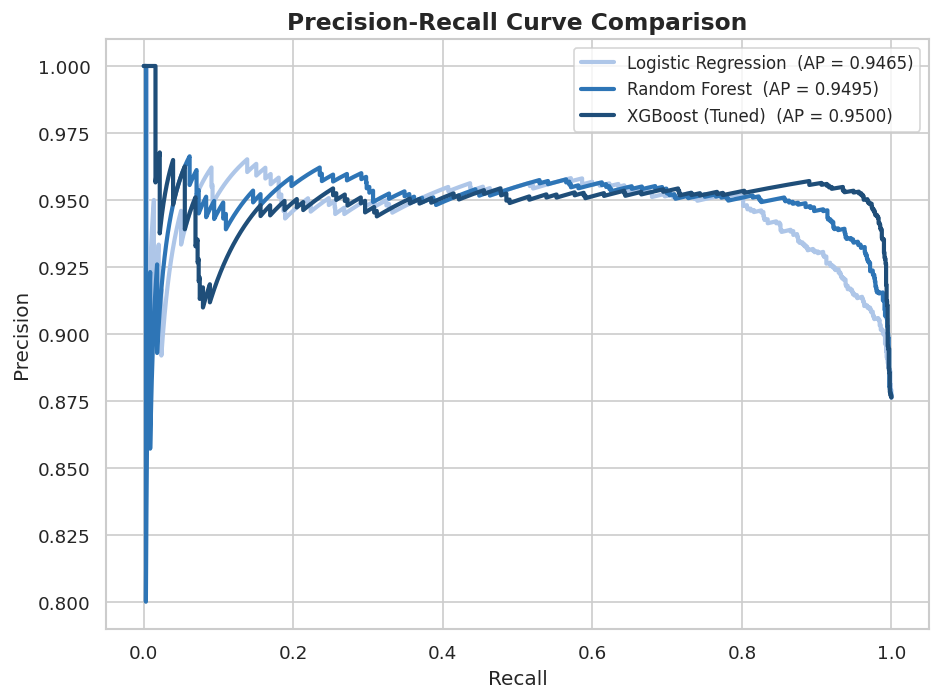

 Saved: 12_precision_recall.png


In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#AEC6E8', '#2E75B6', '#1F4E79']
for (name, model, Xte), color in zip(models_eval, colors):
    y_prob = model.predict_proba(Xte)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec_c, prec_c, color=color, linewidth=2.5,
            label=f'{name}  (AP = {ap:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/12_precision_recall.png', bbox_inches='tight')
plt.show()
print(" Saved: 12_precision_recall.png")

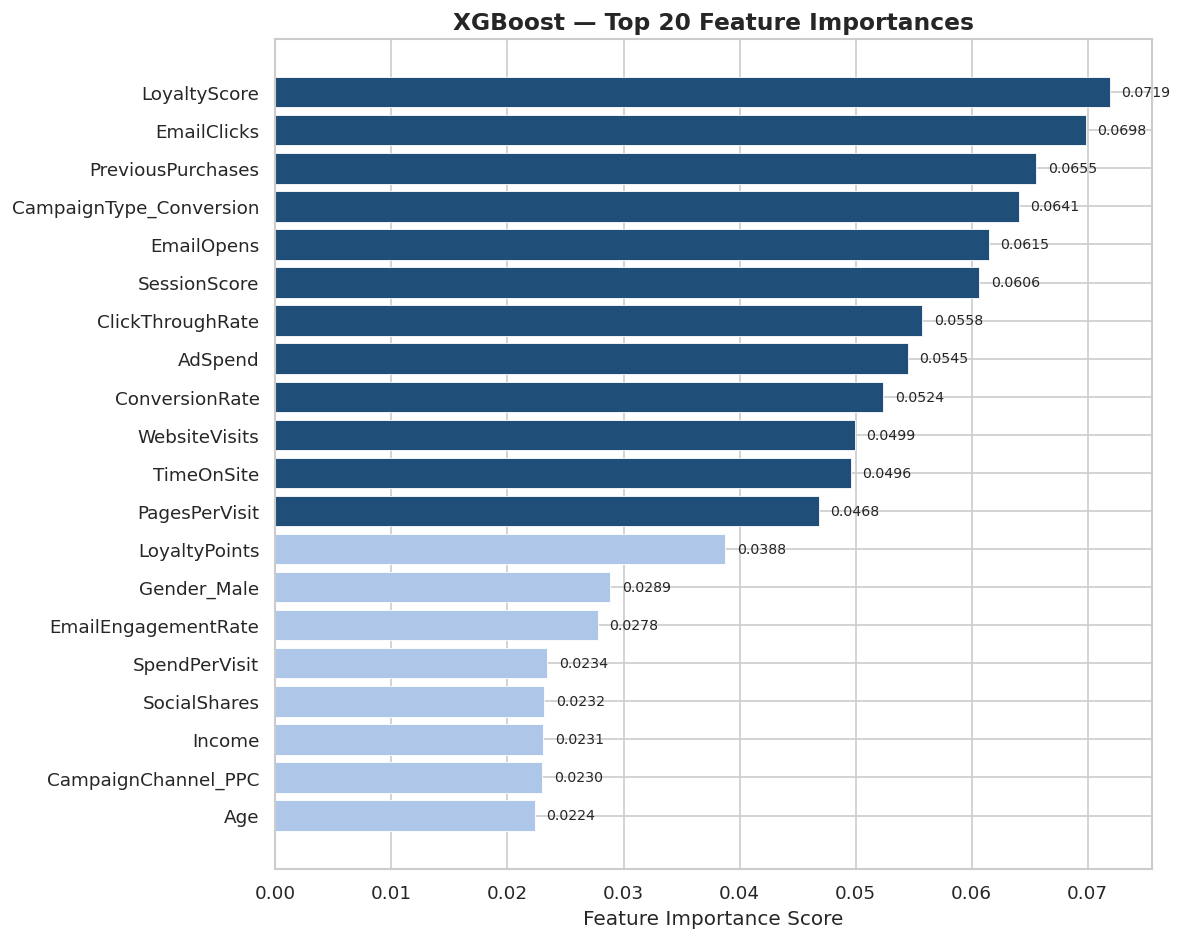

  Saved: 13_feature_importance.png

── Top 10 Most Important Features ───────────────────────
LoyaltyScore               0.0719
EmailClicks                0.0698
PreviousPurchases          0.0655
CampaignType_Conversion    0.0641
EmailOpens                 0.0615
SessionScore               0.0606
ClickThroughRate           0.0558
AdSpend                    0.0545
ConversionRate             0.0524
WebsiteVisits              0.0499


In [34]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8))
colors = ['#1F4E79' if v > feat_imp.median() else '#AEC6E8' 
          for v in feat_imp_sorted.values]
bars = plt.barh(feat_imp_sorted.index, feat_imp_sorted.values,
                color=colors, edgecolor='white', linewidth=0.5)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
for bar, val in zip(bars, feat_imp_sorted.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('../outputs/13_feature_importance.png', bbox_inches='tight')
plt.show()
print("  Saved: 13_feature_importance.png")

print("\n── Top 10 Most Important Features ───────────────────────")
print(feat_imp.sort_values(ascending=False).head(10).round(4).to_string())

Computing SHAP values (takes ~1 minute)...


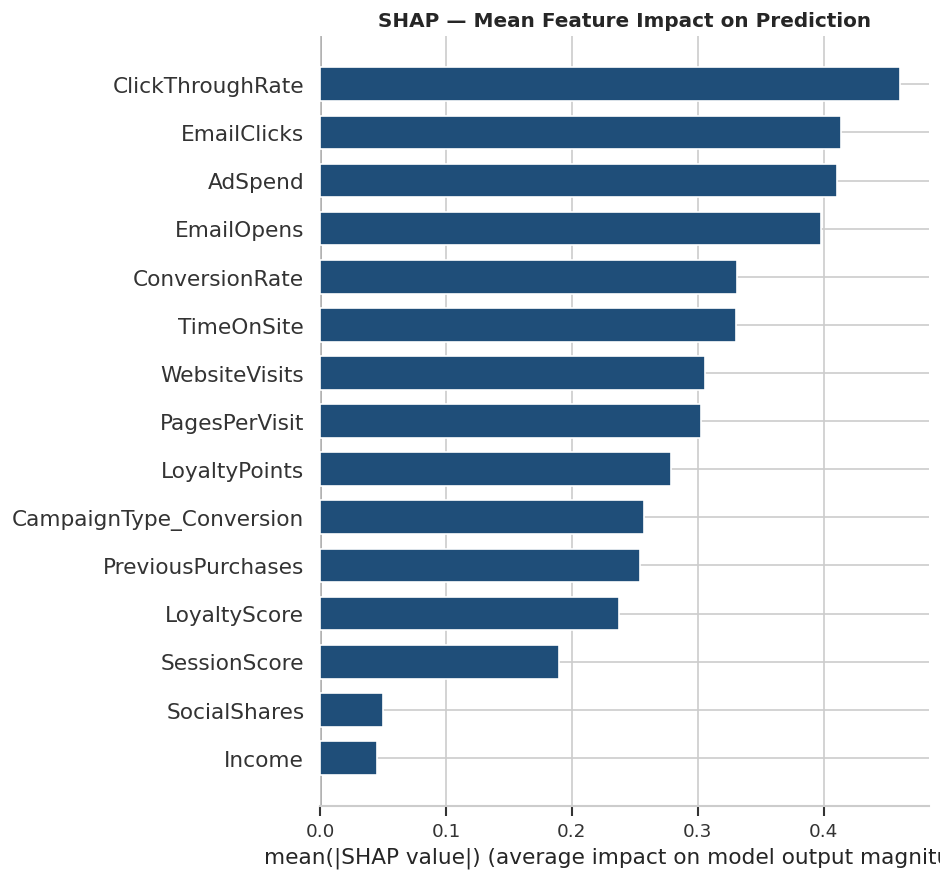

  Saved: 14_shap_bar.png


In [35]:
import shap

print("Computing SHAP values (takes ~1 minute)...")
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  max_display=15,
                  show=False,
                  color='#1F4E79')
plt.title('SHAP — Mean Feature Impact on Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/14_shap_bar.png', bbox_inches='tight')
plt.show()
print("  Saved: 14_shap_bar.png")

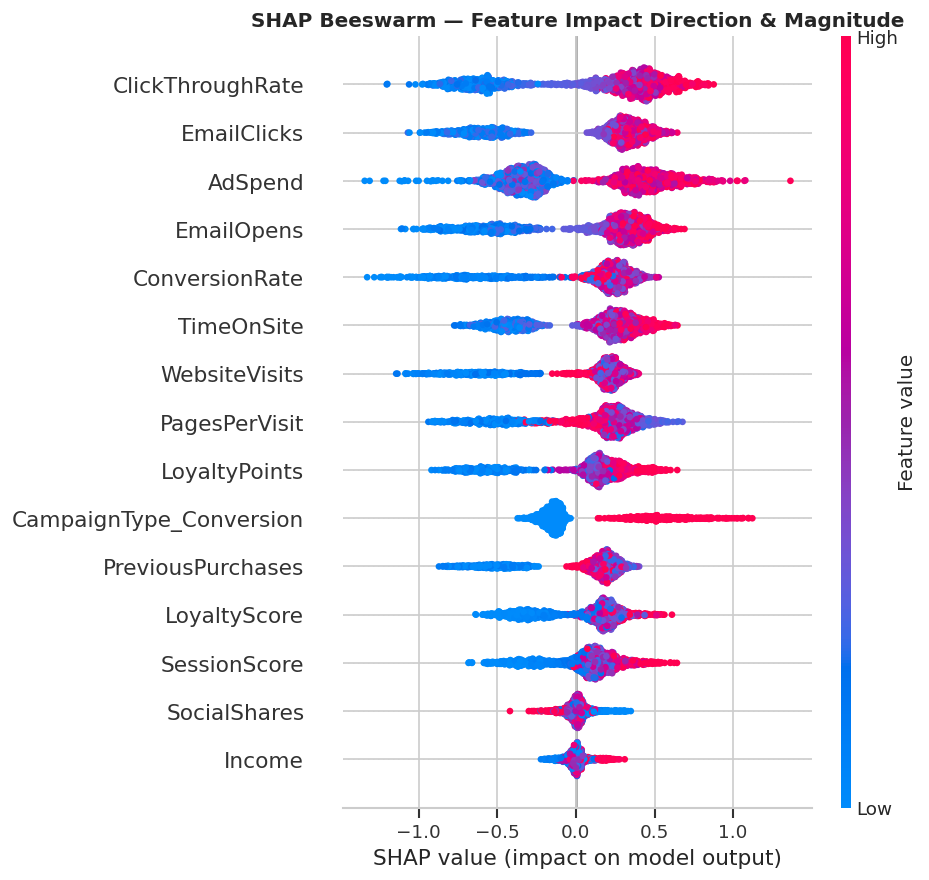

 Saved: 15_shap_beeswarm.png


In [36]:
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/15_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print(" Saved: 15_shap_beeswarm.png")

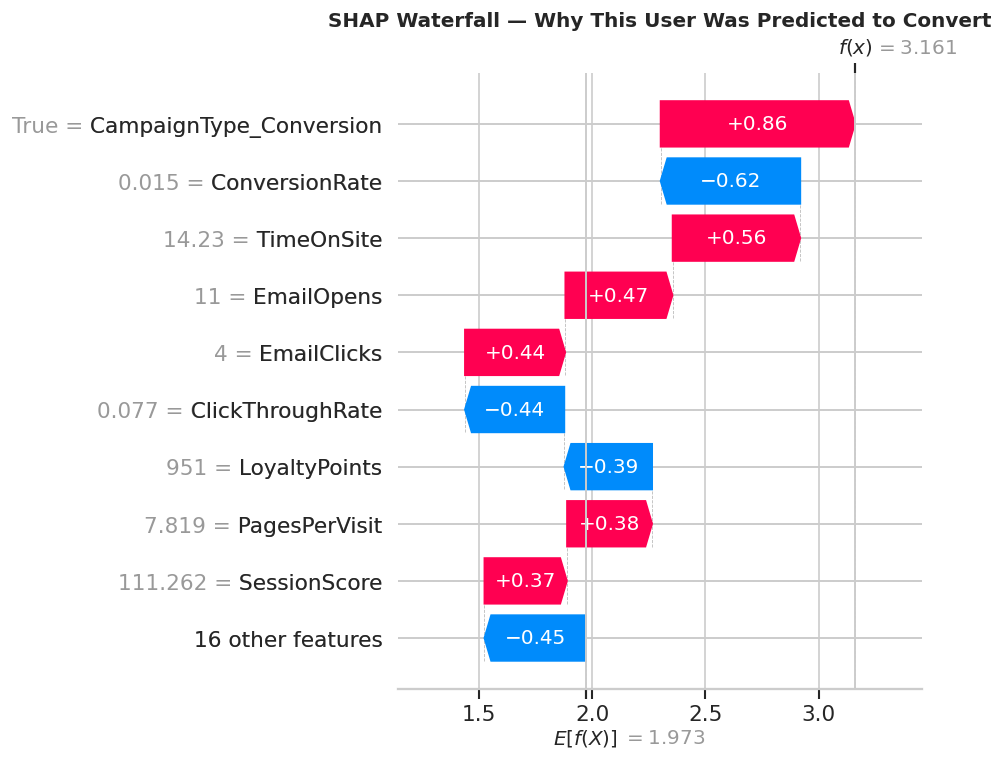

 Saved: 16_shap_waterfall.png


In [37]:
converted_idx   = y_test[y_test == 1].index[:1]
converted_local = X_test.loc[converted_idx]

explanation = shap.Explanation(
    values     = explainer.shap_values(converted_local)[0],
    base_values= explainer.expected_value,
    data       = converted_local.values[0],
    feature_names = X_test.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title('SHAP Waterfall — Why This User Was Predicted to Convert', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/16_shap_waterfall.png', bbox_inches='tight')
plt.show()
print(" Saved: 16_shap_waterfall.png")

In [39]:
import joblib

joblib.dump(best_xgb, '../models/xgboost_conversion_model.pkl')
joblib.dump(scaler,   '../models/standard_scaler.pkl')

print(" Model saved: models/xgboost_conversion_model.pkl")
print(" Scaler saved: models/standard_scaler.pkl")

 Model saved: models/xgboost_conversion_model.pkl
 Scaler saved: models/standard_scaler.pkl


In [40]:
results_df = X_test.copy()
results_df['Actual_Conversion']      = y_test.values
results_df['Predicted_Conversion']   = best_xgb.predict(X_test)
results_df['Conversion_Probability'] = best_xgb.predict_proba(X_test)[:, 1].round(4)

results_df.to_csv('../outputs/predictions.csv', index=False)

print(" Predictions exported: outputs/predictions.csv")
print(f"   Rows: {len(results_df):,}")
print(f"   Columns: {list(results_df.columns[-3:])}")

results_df[['Actual_Conversion','Predicted_Conversion','Conversion_Probability']].head(10)

 Predictions exported: outputs/predictions.csv
   Rows: 1,600
   Columns: ['Actual_Conversion', 'Predicted_Conversion', 'Conversion_Probability']


,Actual_Conversion,Predicted_Conversion,Conversion_Probability
3344,1,1,0.9593
408,1,1,0.9827
5038,1,1,0.9736
6499,0,0,0.3225
4266,1,1,0.9849
3444,1,1,0.8697
4766,1,1,0.9360
3672,1,1,0.9710
2774,1,1,0.9789
3033,1,1,0.9869


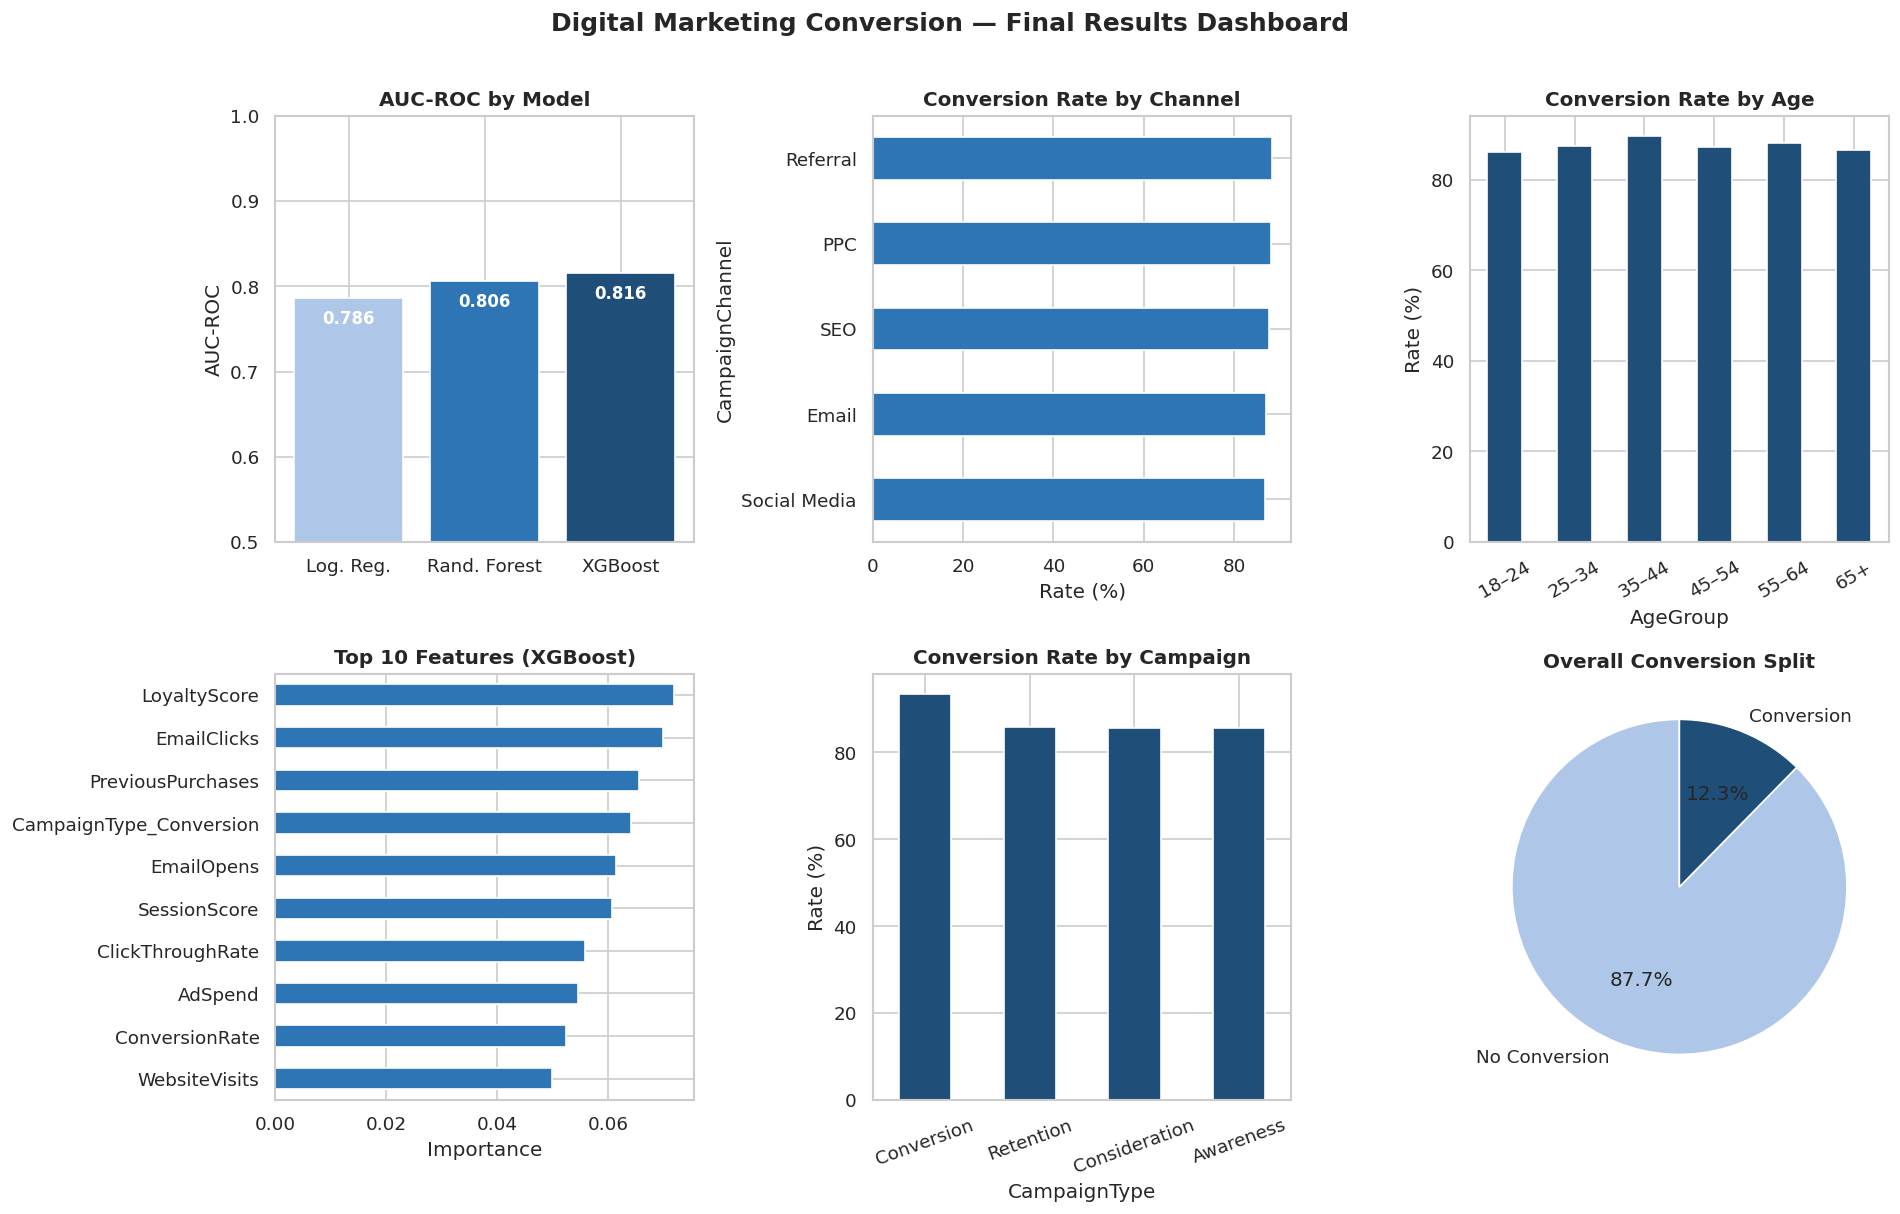

 Final dashboard saved: outputs/00_FINAL_DASHBOARD.png


In [41]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Digital Marketing Conversion — Final Results Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

ax1 = fig.add_subplot(2, 3, 1)
models_names = list(comparison.keys())
auc_vals = [comparison[m]['AUC'] for m in models_names]
short_names = ['Log. Reg.', 'Rand. Forest', 'XGBoost']
bars = ax1.bar(short_names, auc_vals, color=['#AEC6E8','#2E75B6','#1F4E79'], edgecolor='white')
for bar, v in zip(bars, auc_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, v-0.03, f'{v:.3f}',
             ha='center', color='white', fontweight='bold', fontsize=10)
ax1.set_ylim([0.5, 1.0])
ax1.set_title('AUC-ROC by Model', fontweight='bold')
ax1.set_ylabel('AUC-ROC')

ax2 = fig.add_subplot(2, 3, 2)
ch_r = raw_df.groupby('CampaignChannel')['Conversion'].mean()*100
ch_r.sort_values(ascending=True).plot(kind='barh', ax=ax2, color='#2E75B6', edgecolor='white')
ax2.set_title('Conversion Rate by Channel', fontweight='bold')
ax2.set_xlabel('Rate (%)')

ax3 = fig.add_subplot(2, 3, 3)
ag_r = raw_df.groupby('AgeGroup', observed=True)['Conversion'].mean()*100
ag_r.plot(kind='bar', ax=ax3, color='#1F4E79', edgecolor='white')
ax3.set_title('Conversion Rate by Age', fontweight='bold')
ax3.set_ylabel('Rate (%)')
ax3.tick_params(axis='x', rotation=30)

ax4 = fig.add_subplot(2, 3, 4)
top10 = feat_imp.sort_values(ascending=True).tail(10)
top10.plot(kind='barh', ax=ax4, color='#2E75B6', edgecolor='white')
ax4.set_title('Top 10 Features (XGBoost)', fontweight='bold')
ax4.set_xlabel('Importance')

ax5 = fig.add_subplot(2, 3, 5)
ct_r = raw_df.groupby('CampaignType')['Conversion'].mean()*100
ct_r.sort_values(ascending=False).plot(kind='bar', ax=ax5, color='#1F4E79', edgecolor='white')
ax5.set_title('Conversion Rate by Campaign', fontweight='bold')
ax5.set_ylabel('Rate (%)')
ax5.tick_params(axis='x', rotation=20)

ax6 = fig.add_subplot(2, 3, 6)
conv_c = raw_df['Conversion'].value_counts()
ax6.pie(conv_c.values, labels=['No Conversion','Conversion'],
        autopct='%1.1f%%', colors=['#AEC6E8','#1F4E79'], startangle=90)
ax6.set_title('Overall Conversion Split', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/00_FINAL_DASHBOARD.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Final dashboard saved: outputs/00_FINAL_DASHBOARD.png")

In [42]:
import os

print("=" * 55)
print("  PROJECT COMPLETE — ALL OUTPUT FILES")
print("=" * 55)

print("\n outputs/")
for f in sorted(os.listdir('../outputs')):
    size = os.path.getsize(f'../outputs/{f}')
    print(f"   {f:<45} {size/1024:6.1f} KB")

print("\n models/")
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}')
    print(f"   {f:<45} {size/1024:6.1f} KB")

print("\n All done! Your project is complete.")
print(f"\n   Best model   : XGBoost (Tuned)")
print(f"   AUC-ROC      : {comparison['XGBoost (Tuned)']['AUC']:.4f}")
print(f"   Accuracy     : {comparison['XGBoost (Tuned)']['Accuracy']*100:.2f}%")
print(f"   F1-Score     : {comparison['XGBoost (Tuned)']['F1']*100:.2f}%")

  PROJECT COMPLETE — ALL OUTPUT FILES

📁 outputs/
   00_FINAL_DASHBOARD.png                         240.0 KB
   01_target_distribution.png                      21.5 KB
   02_channel_analysis.png                         69.7 KB
   03_campaign_type_analysis.png                   67.2 KB
   04_age_group_analysis.png                       62.2 KB
   05_gender_analysis.png                          52.7 KB
   06_engagement_kde.png                          233.9 KB
   07_correlation_heatmap.png                     135.6 KB
   08_adspend_analysis.png                         69.4 KB
   09_feature_scores.png                           64.6 KB
   10_roc_curves.png                               72.2 KB
   11_confusion_matrices.png                       44.9 KB
   12_precision_recall.png                         82.8 KB
   13_feature_importance.png                      100.9 KB
   14_shap_bar.png                                 75.3 KB
   15_shap_beeswarm.png                           187.9 KB
   16_

In [43]:
import joblib
import pandas as pd

loaded_model = joblib.load('../models/xgboost_conversion_model.pkl')

new_customer = X_test.iloc[[0]].copy()  # Using a test row as example

prob = loaded_model.predict_proba(new_customer)[0][1]
pred = loaded_model.predict(new_customer)[0]

print("── New Customer Prediction ──────────────────────────────")
print(f"  Predicted Class      : {'CONVERTS ' if pred == 1 else 'DOES NOT CONVERT ❌'}")
print(f"  Conversion Probability: {prob*100:.1f}%")
print(f"  Actual (for comparison): {'Converts' if y_test.iloc[0] == 1 else 'No Conversion'}")

── New Customer Prediction ──────────────────────────────
  Predicted Class      : CONVERTS 
  Conversion Probability: 95.9%
  Actual (for comparison): Converts
